In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Preparation

In [18]:
# Set seed for reproducibility
random_seed = 1616
np.random.seed(random_seed)
tf.random.set_seed(random_seed)
initializer = tf.keras.initializers.HeNormal(seed=random_seed)

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Load data
data = np.load('fashion_train.npy')
X_train = data[:, :-1]
y_train = data[:, -1]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Reduce dimensions using PCA
n_components = 112
pca = PCA(n_components=n_components, random_state=1616)
X_pca = pca.fit_transform(X_scaled)


# Model Training

In [19]:
# Convert labels for classification
y_train_categorical = to_categorical(y_train) # one-hot-encoding

# FFNN model
model = Sequential([
    # Hidden layers with ReLU activation
    Dense(128, activation='relu', input_dim=n_components, kernel_initializer=initializer),
    Dropout(0.2, seed=random_seed),
    Dense(64, activation='relu', kernel_initializer=initializer),
    Dense(32, activation='relu', kernel_initializer=initializer),
    Dense(16, activation='relu', kernel_initializer=initializer),
    Dropout(0.2, seed=random_seed),
    # Output layer with softmax activation
    Dense(5, activation='softmax', kernel_initializer=initializer)
])

# Compile the model
model.compile(optimizer=SGD(learning_rate=0.01), # Using stochastic gradient descent
              loss='categorical_crossentropy', # categorical cross-etropy loss
              metrics=['accuracy'])

# Train the model
history = model.fit(X_pca, y_train_categorical, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping])


/opt/homebrew/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4202 - loss: 1.5940 - val_accuracy: 0.7275 - val_loss: 0.7064
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6557 - loss: 0.8109 - val_accuracy: 0.7535 - val_loss: 0.6121
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7017 - loss: 0.7240 - val_accuracy: 0.7685 - val_loss: 0.5702
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7203 - loss: 0.6685 - val_accuracy: 0.7840 - val_loss: 0.5451
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7378 - loss: 0.6391 - val_accuracy: 0.7810 - val_loss: 0.5299
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7572 - loss: 0.6148 - val_accuracy: 0.8005 - val_loss: 0.5109
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7739 - loss: 0.5834 - val_accuracy: 0.8065 - val_loss: 0.4981
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7793 - loss: 0.5743 - val_accu

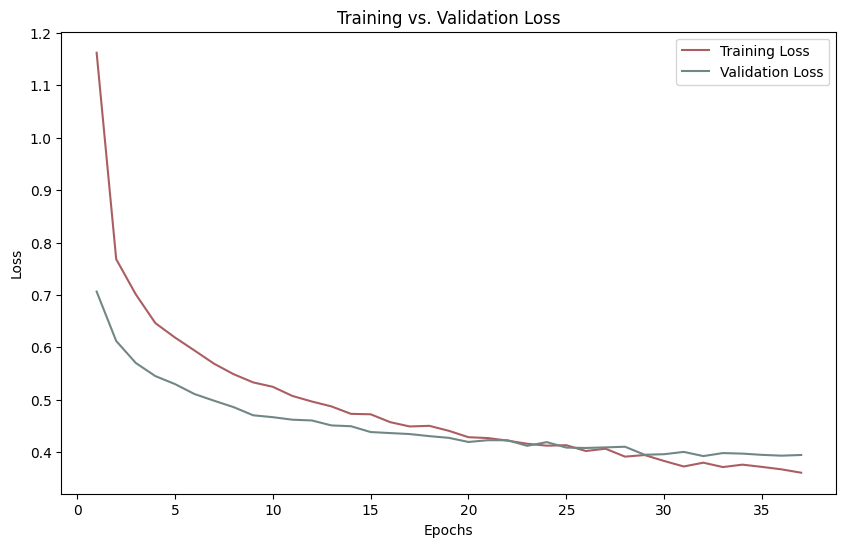

In [20]:
# Extract loss values
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Plot the loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(training_loss) + 1), training_loss, label='Training Loss', color='#AB5E61')
plt.plot(range(1, len(validation_loss) + 1), validation_loss, label='Validation Loss', color='#718786')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()

# Model Testing

In [21]:
# Load the test data
test_data = np.load('fashion_test.npy')
X_test = test_data[:, :-1]
y_test = test_data[:, -1]

# Scale the test data 
X_test_scaled = scaler.transform(X_test)

# Apply PCA
X_test_pca = pca.transform(X_test_scaled) 

# Predict probabilities for each class
y_pred_probabilities = model.predict(X_test_pca)

# Predict class labels (the class with the highest probability)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.2f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test Accuracy: 0.84


## Classification report

In [22]:
# Print a classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']))

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.80      0.81      1000
     Trouser       0.99      0.95      0.97      1000
    Pullover       0.80      0.87      0.83      1000
       Dress       0.87      0.92      0.89      1000
       Shirt       0.70      0.63      0.66      1000

    accuracy                           0.84      5000
   macro avg       0.83      0.84      0.83      5000
weighted avg       0.83      0.84      0.83      5000



# Testing different number of PCs

In [23]:
# PCA components to test
components_list = [21, 30, 44, 68, 112, 210, 359, 784]
# explain -------> 70%,75%,80%,85%,90%, 95%, 98%, 100% variance

# Dictionary to store the accuracy for each number of PCs
results = {}

# Loop over different PCs
for component in components_list:
    # Apply PCA
    pca = PCA(n_components=component, random_state=1616)
    X_train_pca = pca.fit_transform(X_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # Define model as before
    model = Sequential([
        # Hidden layers with ReLU activation
        Dense(128, activation='relu', input_dim=component, kernel_initializer=initializer),
        Dropout(0.2, seed=random_seed),
        Dense(64, activation='relu', kernel_initializer=initializer),
        Dense(32, activation='relu', kernel_initializer=initializer),
        Dense(16, activation='relu', kernel_initializer=initializer),
        Dropout(0.2, seed=random_seed),
        # Output layer with softmax activation
        Dense(5, activation='softmax', kernel_initializer=initializer)
    ])

    # Compile the model
    model.compile(optimizer=SGD(learning_rate=0.01), # Using stochastic gradient descent
                  loss='categorical_crossentropy', # categorical cross-entropy loss
                  metrics=['accuracy']) 

    # Train the model
    model.fit(X_train_pca, y_train_categorical, epochs=100, batch_size=32, 
              validation_split=0.2, callbacks=[early_stopping], verbose=0)
    
    # Evaluate on test data
    y_pred_probabilities = model.predict(X_test_pca)
    y_pred = np.argmax(y_pred_probabilities, axis=1)
    test_accuracy = accuracy_score(y_test, y_pred)
    
    # Store results
    results[component] = test_accuracy

# Display results, played dogeminer2.com while this was loading for sanity
print("\nResults Summary:")
for comp, acc in results.items():
    print(f"Components: {comp}, Accuracy: {acc:.4f}")

/opt/homebrew/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step


/opt/homebrew/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step


/opt/homebrew/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 758us/step


/opt/homebrew/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


/opt/homebrew/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Results Summary:
Components: 21, Accuracy: 0.8038
Components: 30, Accuracy: 0.8208
Components: 44, Accuracy: 0.8326
Components: 68, Accuracy: 0.8294
Components: 112, Accuracy: 0.8352
Components: 210, Accuracy: 0.8420
Components: 359, Accuracy: 0.8436
Components: 784, Accuracy: 0.8436


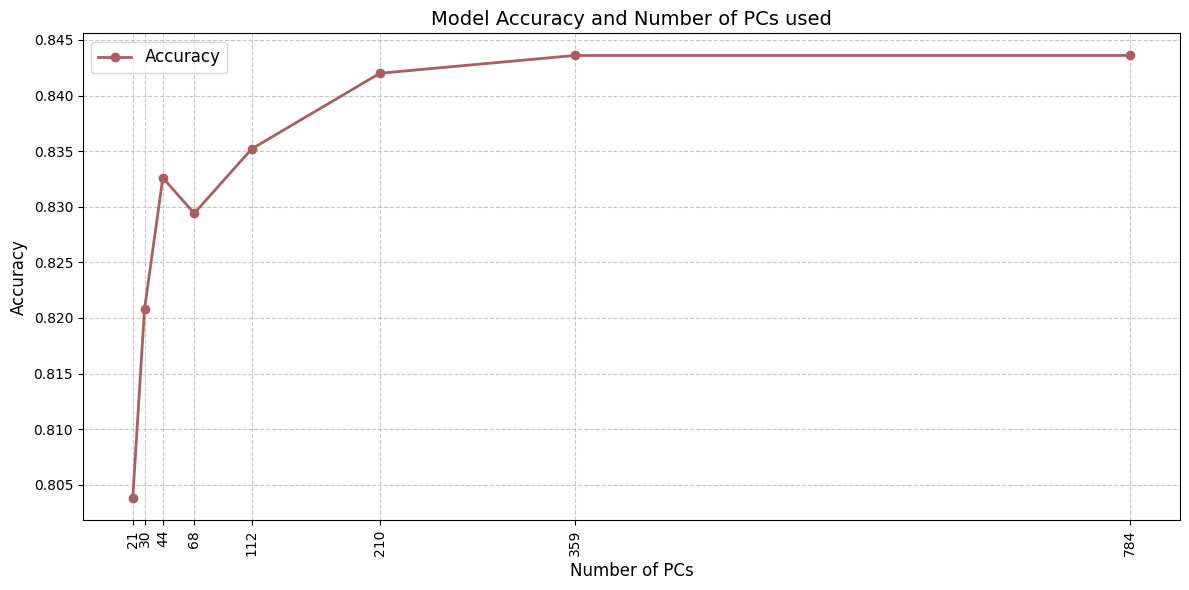

In [24]:
# PLOTTING -----------------------
plt.figure(figsize=(12, 6))

# Extract components and accuracies from results
components_list = list(results.keys())
accuracy = list(results.values())

# Plot the data
plt.plot(components_list, accuracy, marker='o', linestyle='-', linewidth=2, label="Accuracy", color='#AB5E61')

plt.xticks(ticks=components_list, labels=components_list, fontsize=10, rotation=90)
plt.title("Model Accuracy and Number of PCs used", fontsize=14)
plt.xlabel("Number of PCs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7) # grid
plt.legend(fontsize=12) # legends

plt.tight_layout()
plt.show()